# Phishing con Granite Embeddings + MLP

Este notebook implementa un flujo en dos etapas:

1. Cargar y limpiar el dataset de phishing.
2. Extraer embeddings con `ibm-granite/granite-embedding-97m-multilingual-r2`.
3. Guardar esos embeddings en disco.
4. Entrenar un `MLP` offline para clasificacion binaria.

La parte cara es la extraccion de embeddings. Una vez cacheados, el entrenamiento del clasificador se puede repetir sin volver a ejecutar el Transformer.

## 1. Configuracion

Este notebook asume que se ejecuta en el entorno conda `fagos_ESM`.

Salidas principales:

- `artifacts/phishing_clean_metadata.parquet`
- `artifacts/granite_embeddings_full.pt`
- `artifacts/granite_embeddings_partial.pt`
- `artifacts/mlp_model.pt`

In [1]:
from __future__ import annotations

import hashlib
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

sns.set_theme(style='whitegrid')

SEED = 42
DATA_PATH = Path('dataset/phishing_email.csv')
ARTIFACT_DIR = Path('artifacts')
MODEL_NAME = 'ibm-granite/granite-embedding-97m-multilingual-r2'
FULL_CACHE = ARTIFACT_DIR / 'granite_embeddings_full.pt'
PARTIAL_CACHE = ARTIFACT_DIR / 'granite_embeddings_partial.pt'
METADATA_PATH = ARTIFACT_DIR / 'phishing_clean_metadata.parquet'
MLP_PATH = ARTIFACT_DIR / 'mlp_model.pt'

BATCH_SIZE_EMBED = 16
BATCH_SIZE_MLP = 256
MAX_LENGTH = 4096
TEST_SIZE = 0.15
VAL_SIZE = 0.15
MAX_EPOCHS = 50
PATIENCE = 6
LR = 1e-3
WEIGHT_DECAY = 1e-4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything()
ARTIFACT_DIR.mkdir(exist_ok=True)
print('device:', DEVICE)
print('dataset:', DATA_PATH.resolve())
print('model:', MODEL_NAME)


device: cuda
dataset: /home/randy/Python/Phishing/dataset/phishing_email.csv
model: ibm-granite/granite-embedding-97m-multilingual-r2


## 2. Carga y exploracion

El archivo canónico es `dataset/phishing_email.csv`. Las otras tablas en `dataset/` son las fuentes parciales que alimentaron ese archivo unificado.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontro {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH)
print('shape:', df_raw.shape)
display(df_raw.head())
print('columns:', df_raw.columns.tolist())
print('label counts:')
display(df_raw['label'].value_counts(dropna=False).sort_index())
print('missing values:')
display(df_raw.isna().sum())

text_lengths = df_raw['text_combined'].fillna('').astype(str).str.len()
display(text_lengths.describe(percentiles=[0.5, 0.9, 0.99]).to_frame().T)
print('empty texts:', int((df_raw['text_combined'].fillna('').astype(str).str.strip() == '').sum()))
print('duplicate texts:', int(df_raw['text_combined'].fillna('').astype(str).duplicated().sum()))


shape: (82486, 2)


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


columns: ['text_combined', 'label']
label counts:


label
0    39595
1    42891
Name: count, dtype: int64

missing values:


text_combined    0
label            0
dtype: int64

,count,mean,std,min,50%,90%,99%,max
text_combined,82486.0,1288.751218,15496.745845,1.0,558.0,2764.0,9014.1,4279526.0


empty texts: 1
duplicate texts: 408


## 3. Limpieza y split sin fuga

La limpieza es deliberadamente conservadora: solo se elimina texto vacio y se normaliza el espaciado. No se eliminan duplicados, pero el split se hace por `text_hash` para que el mismo correo no aparezca en particiones distintas.

In [4]:
def normalize_text(value: object) -> str:
    if pd.isna(value):
        return ''
    text = str(value)
    text = ' '.join(text.split())
    return text.strip()


def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode('utf-8')).hexdigest()


def choose_best_fold(splitter, X, y, groups, target_fraction: float):
    y = np.asarray(y)
    total_pos_rate = float(y.mean())
    best = None
    for fold_id, (_, fold_idx) in enumerate(splitter.split(X, y, groups)):
        fold_mask = np.zeros(len(y), dtype=bool)
        fold_mask[fold_idx] = True
        fold_fraction = float(fold_mask.mean())
        if fold_mask.sum() == 0:
            continue
        fold_pos_rate = float(y[fold_mask].mean())
        score = abs(fold_fraction - target_fraction) + 0.35 * abs(fold_pos_rate - total_pos_rate)
        candidate = {
            'score': score,
            'fold_id': fold_id,
            'fold_idx': np.asarray(fold_idx),
            'fold_fraction': fold_fraction,
            'fold_pos_rate': fold_pos_rate,
        }
        if best is None or candidate['score'] < best['score']:
            best = candidate
    if best is None:
        raise RuntimeError('No se pudo elegir un fold valido')
    return best


df = df_raw.copy()
df['row_id'] = np.arange(len(df), dtype=np.int64)
df['text'] = df['text_combined'].map(normalize_text)
df = df[df['text'] != ''].copy()
df['label'] = df['label'].astype(int)
df['text_hash'] = df['text'].map(sha256_text)

print('clean shape:', df.shape)
print('label counts after cleaning:')
display(df['label'].value_counts().sort_index())
print('unique hashes:', df['text_hash'].nunique())
print('duplicate extra rows:', int(df['text_hash'].duplicated().sum()))

hash_label_nunique = df.groupby('text_hash')['label'].nunique()
if (hash_label_nunique > 1).any():
    conflict_counts = int((hash_label_nunique > 1).sum())
    raise ValueError(f'Hay {conflict_counts} hashes con etiquetas conflictivas; no se puede splittear de forma segura por hash')

hash_df = (
    df.groupby('text_hash', as_index=False)
      .agg(label=('label', 'first'))
 )

X_hash = np.zeros(len(hash_df), dtype=np.int8)
y_hash = hash_df['label'].to_numpy()
groups_hash = hash_df['text_hash'].to_numpy()

outer = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
best_test = choose_best_fold(outer, X_hash, y_hash, groups_hash, target_fraction=TEST_SIZE)
test_hashes = set(hash_df.iloc[best_test['fold_idx']]['text_hash'])

remaining_hash_df = hash_df[~hash_df['text_hash'].isin(test_hashes)].reset_index(drop=True)
inner_X = np.zeros(len(remaining_hash_df), dtype=np.int8)
inner_y = remaining_hash_df['label'].to_numpy()
inner_groups = remaining_hash_df['text_hash'].to_numpy()
inner_target = VAL_SIZE / (1.0 - TEST_SIZE)
inner = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED + 1)
best_val = choose_best_fold(inner, inner_X, inner_y, inner_groups, target_fraction=inner_target)
val_hashes = set(remaining_hash_df.iloc[best_val['fold_idx']]['text_hash'])

split_by_hash = hash_df[['text_hash']].copy()
split_by_hash['split'] = 'train'
split_by_hash.loc[split_by_hash['text_hash'].isin(val_hashes), 'split'] = 'val'
split_by_hash.loc[split_by_hash['text_hash'].isin(test_hashes), 'split'] = 'test'

split_df = df.merge(split_by_hash, on='text_hash', how='left').sort_values('row_id').reset_index(drop=True)

hash_split_counts = split_df.groupby('text_hash')['split'].nunique()
if not (hash_split_counts == 1).all():
    raise AssertionError('Hay fuga de hashes entre splits')

print('split counts:')
display(split_df['split'].value_counts())
print('split label table:')
display(pd.crosstab(split_df['split'], split_df['label']))

metadata = split_df[['row_id', 'text', 'label', 'text_hash', 'split']].copy()
metadata.to_parquet(METADATA_PATH, index=False)
print('saved metadata ->', METADATA_PATH)


clean shape: (82485, 5)
label counts after cleaning:


label
0    39595
1    42890
Name: count, dtype: int64

unique hashes: 82077
duplicate extra rows: 408
split counts:


split
train    58924
val      11781
test     11780
Name: count, dtype: int64

split label table:


label,0,1
split,,
test,5638,6142
train,28291,30633
val,5666,6115


saved metadata -> artifacts/phishing_clean_metadata.parquet


## 4. Extraccion de embeddings

Granite se usa con `transformers` directo. El embedding se toma desde `last_hidden_state[:, 0]` y luego se normaliza con `L2`. El resultado final se guarda en `.pt` para reutilizarlo sin recalcular el Transformer.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
encoder.eval()


def encode_batch(texts: list[str]) -> torch.Tensor:
    batch = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt',
    )
    batch = {key: value.to(DEVICE) for key, value in batch.items()}
    with torch.inference_mode():
        if DEVICE.type == 'cuda':
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = encoder(**batch)
        else:
            outputs = encoder(**batch)
        embeddings = outputs.last_hidden_state[:, 0]
        embeddings = F.normalize(embeddings, p=2, dim=1)
    return embeddings.float().cpu()


def build_embedding_cache(frame: pd.DataFrame, batch_size: int = BATCH_SIZE_EMBED, checkpoint_every: int = 200) -> dict:
    if FULL_CACHE.exists():
        print('cargando cache completo:', FULL_CACHE)
        return torch.load(FULL_CACHE, map_location='cpu', weights_only=False)

    start_index = 0
    chunks = []
    row_ids = []
    labels = []
    hashes = []

    if PARTIAL_CACHE.exists():
        partial = torch.load(PARTIAL_CACHE, map_location='cpu', weights_only=False)
        start_index = int(partial['next_index'])
        chunks.append(partial['embeddings'])
        row_ids.extend(partial['row_ids'])
        labels.extend(partial['labels'])
        hashes.extend(partial['text_hashes'])
        print('reanudando desde', start_index)

    texts = frame['text'].tolist()
    all_row_ids = frame['row_id'].tolist()
    all_labels = frame['label'].tolist()
    all_hashes = frame['text_hash'].tolist()

    batches = range(start_index, len(texts), batch_size)
    for batch_number, batch_start in enumerate(tqdm(batches, desc='embedding', total=math.ceil((len(texts) - start_index) / batch_size))):
        batch_end = min(batch_start + batch_size, len(texts))
        batch_texts = texts[batch_start:batch_end]
        batch_embeddings = encode_batch(batch_texts)
        chunks.append(batch_embeddings)
        row_ids.extend(all_row_ids[batch_start:batch_end])
        labels.extend(all_labels[batch_start:batch_end])
        hashes.extend(all_hashes[batch_start:batch_end])

        if (batch_number + 1) % checkpoint_every == 0 or batch_end == len(texts):
            partial_state = {
                'embeddings': torch.cat(chunks, dim=0),
                'row_ids': row_ids,
                'labels': labels,
                'text_hashes': hashes,
                'next_index': batch_end,
                'model_name': MODEL_NAME,
            }
            torch.save(partial_state, PARTIAL_CACHE)
            print('checkpoint guardado en', PARTIAL_CACHE)

    embeddings = torch.cat(chunks, dim=0)
    payload = {
        'embeddings': embeddings,
        'row_ids': row_ids,
        'labels': labels,
        'text_hashes': hashes,
        'model_name': MODEL_NAME,
        'max_length': MAX_LENGTH,
        'created_at': pd.Timestamp.utcnow().isoformat(),
    }
    torch.save(payload, FULL_CACHE)
    if PARTIAL_CACHE.exists():
        PARTIAL_CACHE.unlink()
    return payload


embedding_cache = build_embedding_cache(split_df)
print('embeddings shape:', tuple(embedding_cache['embeddings'].shape))
print('embedding dtype:', embedding_cache['embeddings'].dtype)
print('norm sample:', embedding_cache['embeddings'][:3].norm(dim=1))

if embedding_cache['embeddings'].shape[1] != 384:
    raise AssertionError('Se esperaba una dimension de embedding de 384')

if torch.isnan(embedding_cache['embeddings']).any() or torch.isinf(embedding_cache['embeddings']).any():
    raise AssertionError('Los embeddings contienen NaN o inf')


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/25.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/871 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/195M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/74 [00:00<?, ?it/s]

embedding:   0%|          | 0/5156 [00:00<?, ?it/s]

checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_partial.pt
checkpoint guardado en artifacts/granite_embeddings_par

## 5. Entrenamiento offline del MLP

A partir de aqui ya no se vuelve a cargar Granite para entrenar. El clasificador trabaja solo con los tensores guardados en `artifacts/granite_embeddings_full.pt`.

In [6]:
cache = torch.load(FULL_CACHE, map_location='cpu', weights_only=False)
metadata = pd.read_parquet(METADATA_PATH).sort_values('row_id').reset_index(drop=True)

embedding_index = pd.Index(cache['row_ids'])
metadata = metadata.set_index('row_id').loc[embedding_index].reset_index()
embeddings = cache['embeddings'].float()
labels = torch.tensor(cache['labels'], dtype=torch.long)

split_masks = {name: metadata['split'].eq(name).to_numpy() for name in ['train', 'val', 'test']}
X_train = embeddings[split_masks['train']]
y_train = labels[split_masks['train']]
X_val = embeddings[split_masks['val']]
y_val = labels[split_masks['val']]
X_test = embeddings[split_masks['test']]
y_test = labels[split_masks['test']]

print('train/val/test sizes:', len(X_train), len(X_val), len(X_test))

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE_MLP,
    shuffle=True,
    pin_memory=DEVICE.type == 'cuda',
)
val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=BATCH_SIZE_MLP,
    shuffle=False,
    pin_memory=DEVICE.type == 'cuda',
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=BATCH_SIZE_MLP,
    shuffle=False,
    pin_memory=DEVICE.type == 'cuda',
)


class PhishingMLP(nn.Module):
    def __init__(self, input_dim: int = 384):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def evaluate_model(model: nn.Module, loader: DataLoader):
    model.eval()
    all_logits = []
    all_targets = []
    with torch.inference_mode():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            all_logits.append(logits.detach().cpu())
            all_targets.append(yb.detach().cpu())
    logits = torch.cat(all_logits, dim=0)
    targets = torch.cat(all_targets, dim=0).numpy()
    probs = torch.softmax(logits, dim=1).numpy()
    preds = probs.argmax(axis=1)

    precision, recall, f1, support = precision_recall_fscore_support(targets, preds, labels=[0, 1], zero_division=0)
    metrics = {
        'accuracy': accuracy_score(targets, preds),
        'precision_0': float(precision[0]),
        'recall_0': float(recall[0]),
        'f1_0': float(f1[0]),
        'precision_1': float(precision[1]),
        'recall_1': float(recall[1]),
        'f1_1': float(f1[1]),
        'macro_f1': float(f1.mean()),
        'support_0': int(support[0]),
        'support_1': int(support[1]),
    }
    try:
        metrics['roc_auc'] = float(roc_auc_score(targets, probs[:, 1]))
    except ValueError:
        metrics['roc_auc'] = float('nan')
    return metrics, targets, preds, probs


mlp = PhishingMLP(input_dim=embeddings.shape[1]).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = []
best_val_score = -1.0
best_state = None
best_epoch = 0
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    mlp.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = mlp(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(float(loss.item()))

    val_metrics, _, _, _ = evaluate_model(mlp, val_loader)
    train_loss = float(np.mean(train_losses)) if train_losses else float('nan')
    row = {'epoch': epoch, 'train_loss': train_loss, **val_metrics}
    history.append(row)
    print(f"epoch {epoch:02d} | train_loss={train_loss:.4f} | val_macro_f1={val_metrics['macro_f1']:.4f} | val_acc={val_metrics['accuracy']:.4f}")

    if val_metrics['macro_f1'] > best_val_score + 1e-5:
        best_val_score = val_metrics['macro_f1']
        best_state = {
            'model_state_dict': mlp.state_dict(),
            'model_config': {'input_dim': embeddings.shape[1]},
            'epoch': epoch,
            'val_metrics': val_metrics,
        }
        best_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print('early stopping')
        break

if best_state is None:
    raise RuntimeError('No se obtuvo un modelo valido')

mlp.load_state_dict(best_state['model_state_dict'])
torch.save(
    {
        **best_state,
        'history': history,
        'best_epoch': best_epoch,
        'model_name': MODEL_NAME,
    },
    MLP_PATH,
)
print('saved model ->', MLP_PATH)

history_df = pd.DataFrame(history)
display(history_df.tail())


train/val/test sizes: 58924 11781 11780
epoch 01 | train_loss=0.1511 | val_macro_f1=0.9637 | val_acc=0.9638
epoch 02 | train_loss=0.0866 | val_macro_f1=0.9699 | val_acc=0.9700
epoch 03 | train_loss=0.0674 | val_macro_f1=0.9725 | val_acc=0.9725
epoch 04 | train_loss=0.0577 | val_macro_f1=0.9718 | val_acc=0.9718
epoch 05 | train_loss=0.0500 | val_macro_f1=0.9756 | val_acc=0.9756
epoch 06 | train_loss=0.0428 | val_macro_f1=0.9748 | val_acc=0.9748
epoch 07 | train_loss=0.0377 | val_macro_f1=0.9751 | val_acc=0.9751
epoch 08 | train_loss=0.0345 | val_macro_f1=0.9745 | val_acc=0.9745
epoch 09 | train_loss=0.0312 | val_macro_f1=0.9747 | val_acc=0.9747
epoch 10 | train_loss=0.0277 | val_macro_f1=0.9756 | val_acc=0.9756
epoch 11 | train_loss=0.0267 | val_macro_f1=0.9750 | val_acc=0.9750
early stopping
saved model -> artifacts/mlp_model.pt


,epoch,train_loss,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,macro_f1,support_0,support_1,roc_auc
6,7,0.037732,0.975129,0.977261,0.970879,0.974059,0.973179,0.979068,0.976115,0.975087,5666,6115,0.997170
7,8,0.034533,0.974535,0.977232,0.969643,0.973423,0.972073,0.979068,0.975558,0.974491,5666,6115,0.997158
8,9,0.031212,0.974705,0.969559,0.978115,0.973818,0.979555,0.971545,0.975534,0.974676,5666,6115,0.997159
9,10,0.027659,0.975639,0.975261,0.974056,0.974658,0.975988,0.977105,0.976547,0.975602,5666,6115,0.997082
10,11,0.026736,0.975045,0.973387,0.974762,0.974074,0.976584,0.975307,0.975945,0.975010,5666,6115,0.997137


## 6. Evaluacion final

Se reportan metricas sobre `test`, junto con la matriz de confusion y el `classification_report`.

,value
accuracy,0.975722
precision_0,0.971958
recall_0,0.977474
f1_0,0.974708
precision_1,0.979214
recall_1,0.974113
f1_1,0.976657
macro_f1,0.975683
support_0,5638.000000
support_1,6142.000000


              precision    recall  f1-score   support

 no_phishing       0.97      0.98      0.97      5638
    phishing       0.98      0.97      0.98      6142

    accuracy                           0.98     11780
   macro avg       0.98      0.98      0.98     11780
weighted avg       0.98      0.98      0.98     11780



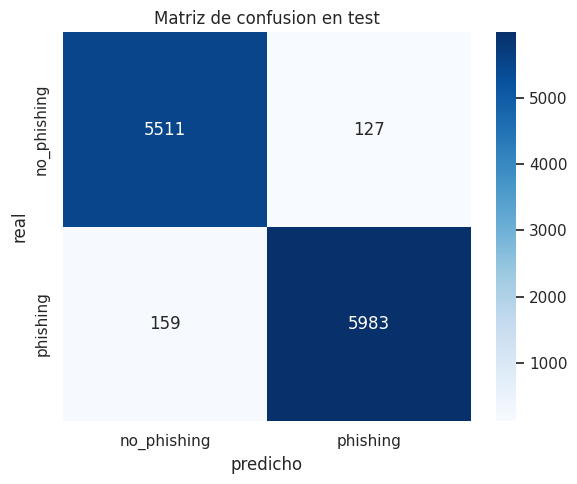

saved metrics -> artifacts/test_metrics.json


In [7]:
test_metrics, y_true, y_pred, y_prob = evaluate_model(mlp, test_loader)
display(pd.DataFrame([test_metrics]).T.rename(columns={0: 'value'}))
print(classification_report(y_true, y_pred, target_names=['no_phishing', 'phishing'], zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no_phishing', 'phishing'], yticklabels=['no_phishing', 'phishing'])
plt.xlabel('predicho')
plt.ylabel('real')
plt.title('Matriz de confusion en test')
plt.tight_layout()
plt.show()

test_metrics_path = ARTIFACT_DIR / 'test_metrics.json'
pd.Series(test_metrics).to_json(test_metrics_path, indent=2)
print('saved metrics ->', test_metrics_path)


## 7. Inferencia

La funcion siguiente permite clasificar un correo nuevo usando el mismo preprocesamiento, el mismo encoder Granite y el mismo MLP ya entrenado.

In [8]:
def predict_email(text: str) -> dict:
    cleaned = normalize_text(text)
    if cleaned == '':
        raise ValueError('El texto de entrada esta vacio')

    embedding = encode_batch([cleaned]).to(DEVICE)
    mlp.eval()
    with torch.inference_mode():
        logits = mlp(embedding)
        prob = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

    label = int(prob.argmax())
    return {
        'label': label,
        'is_phishing': bool(label == 1),
        'prob_no_phishing': float(prob[0]),
        'prob_phishing': float(prob[1]),
    }


sample = 'Urgent account verification required. Click the link immediately to avoid suspension.'
predict_email(sample)


{'label': 1,
 'is_phishing': True,
 'prob_no_phishing': 1.726907976262737e-05,
 'prob_phishing': 0.9999827146530151}

## 8. Notas finales

Si quieres reentrenar solo el clasificador, basta con volver a cargar `artifacts/granite_embeddings_full.pt` y `artifacts/phishing_clean_metadata.parquet`. No hace falta repetir la inferencia de Granite mientras el cache exista.